# Supply Chain ML — 4 Perspectives
**Perspective 1:** Sales & Customer | **Perspective 2:** Inventory & Stockout | **Perspective 3:** Supplier & Procurement | **Perspective 4:** Production Quality

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_absolute_error, r2_score
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression

import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded!')

Libraries loaded!


In [3]:
# ── Load all tables ───
sales        = pd.read_csv('engineered_features/sales_features.csv')
customer     = pd.read_csv('engineered_features/customer_profile.csv')
product      = pd.read_csv('engineered_features/product_profile.csv')
inventory    = pd.read_csv('engineered_features/inventory_features.csv')
procurement  = pd.read_csv('engineered_features/procurement_features.csv')
supplier     = pd.read_csv('engineered_features/supplier_profile.csv')
production   = pd.read_csv('engineered_features/production_features.csv')
shipment     = pd.read_csv('engineered_features/shipment_features.csv')

print('Shapes:')
for name, df in [('sales', sales), ('customer', customer), ('product', product),
                 ('inventory', inventory), ('procurement', procurement),
                 ('supplier', supplier), ('production', production), ('shipment', shipment)]:
    print(f'  {name:15s}: {df.shape}')

Shapes:
  sales          : (100000, 19)
  customer       : (5, 6)
  product        : (20, 6)
  inventory      : (8000, 11)
  procurement    : (3000, 15)
  supplier       : (10, 7)
  production     : (9000, 12)
  shipment       : (12000, 17)


---
## Perspective 1 — Sales & Customer
**Goal:** Predict whether a sale will be high-profit (`high_profit`)  
**Model:** Random Forest Classifier

In [4]:
# ── 1. Prepare data ────
df1 = sales[['quantity_sold', 'unit_price', 'discount_pct',
              'gross_revenue', 'total_cost', 'profit_margin_pct',
              'discount_impact', 'revenue_per_unit', 'high_profit']].dropna()

X1 = df1.drop('high_profit', axis=1)
y1 = df1['high_profit']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
print(f'Train: {X1_train.shape} | Test: {X1_test.shape}')
print(f'Target balance:\n{y1.value_counts(normalize=True).round(2)}')

Train: (80000, 8) | Test: (20000, 8)
Target balance:
high_profit
0    0.5
1    0.5
Name: proportion, dtype: float64


In [5]:
# ── 2. Train ───
model1 = RandomForestClassifier(n_estimators=100, random_state=42)
model1.fit(X1_train, y1_train)

y1_pred = model1.predict(X1_test)
print(classification_report(y1_test, y1_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9964
           1       1.00      1.00      1.00     10036

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



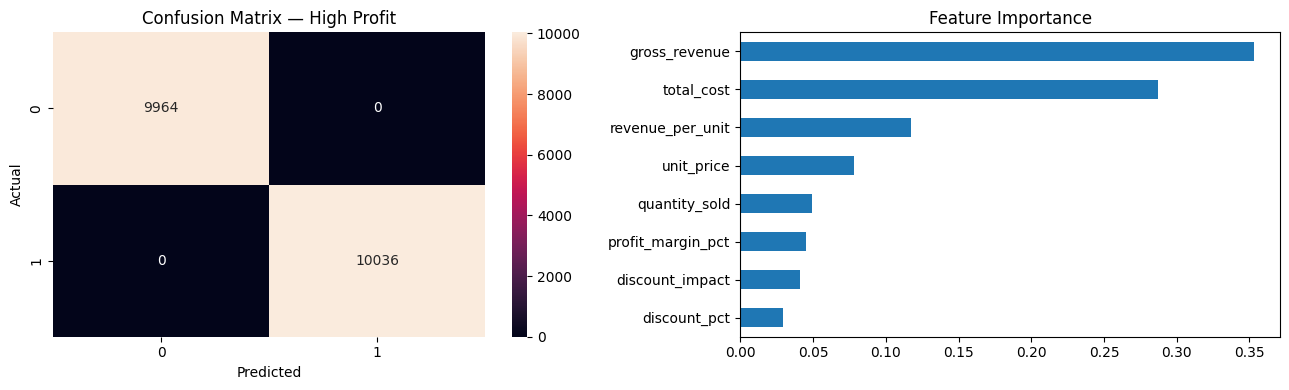

In [6]:
# ── 3. Visualise ───
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
cm = confusion_matrix(y1_test, y1_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Confusion Matrix — High Profit')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance
importance = pd.Series(model1.feature_importances_, index=X1.columns).sort_values()
importance.plot(kind='barh', ax=axes[1])
axes[1].set_title('Feature Importance')

plt.tight_layout()
plt.show()

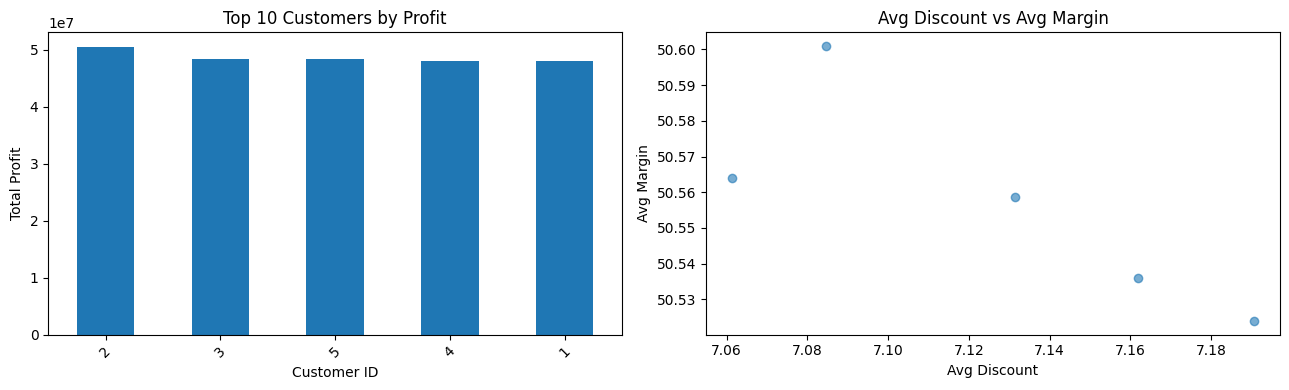

In [7]:
# ── 4. Customer-level insight ────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

customer.sort_values('total_profit', ascending=False).head(10).plot(
    x='customer_id', y='total_profit', kind='bar', ax=axes[0], legend=False)
axes[0].set_title('Top 10 Customers by Profit')
axes[0].set_xlabel('Customer ID')
axes[0].set_ylabel('Total Profit')
axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(customer['avg_discount'], customer['avg_margin'], alpha=0.6)
axes[1].set_title('Avg Discount vs Avg Margin')
axes[1].set_xlabel('Avg Discount')
axes[1].set_ylabel('Avg Margin')

plt.tight_layout()
plt.show()

---
## Perspective 2 — Inventory & Stockout Risk
**Goal:** Predict `stockout_risk` (binary)  
**Model:** Logistic Regression

In [8]:
# ── 1. Prepare data ───
df2 = inventory[['stock_level', 'safety_stock_level', 'reorder_point',
                  'stock_coverage', 'reorder_gap', 'is_overstocked', 'stockout_risk']].dropna()

X2 = df2.drop('stockout_risk', axis=1)
y2 = df2['stockout_risk']

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2_scaled, y2, test_size=0.2, random_state=42)
print(f'Train: {X2_train.shape} | Test: {X2_test.shape}')
print(f'Stockout rate: {y2.mean():.2%}')

Train: (6400, 6) | Test: (1600, 6)
Stockout rate: 18.06%


In [9]:
# ── 2. Train ───
model2 = LogisticRegression(max_iter=1000, random_state=42)
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)
print(classification_report(y2_test, y2_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1322
           1       0.99      0.98      0.99       278

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600



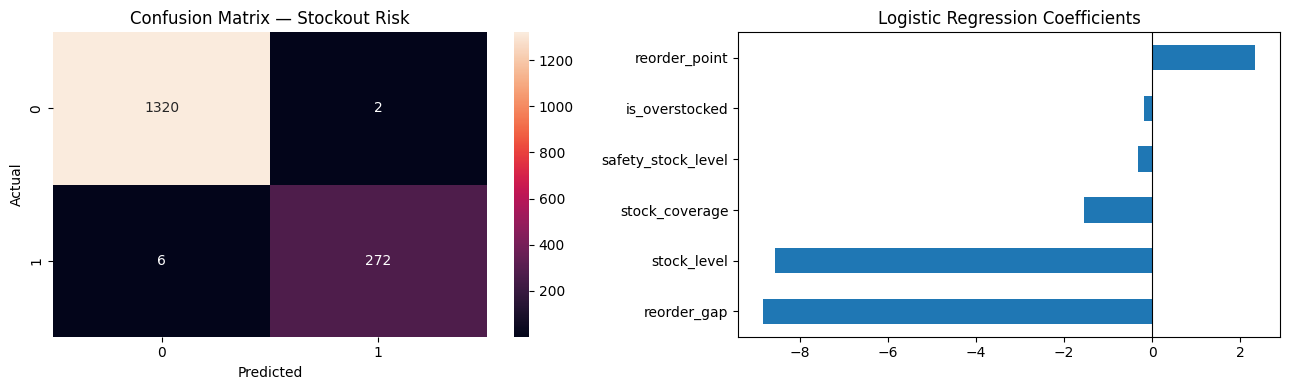

In [10]:
# ── 3. Visualise ───
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
cm2 = confusion_matrix(y2_test, y2_pred)
sns.heatmap(cm2, annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Confusion Matrix — Stockout Risk')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Coefficients
coef = pd.Series(model2.coef_[0], index=X2.columns).sort_values()
coef.plot(kind='barh', ax=axes[1])
axes[1].set_title('Logistic Regression Coefficients')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

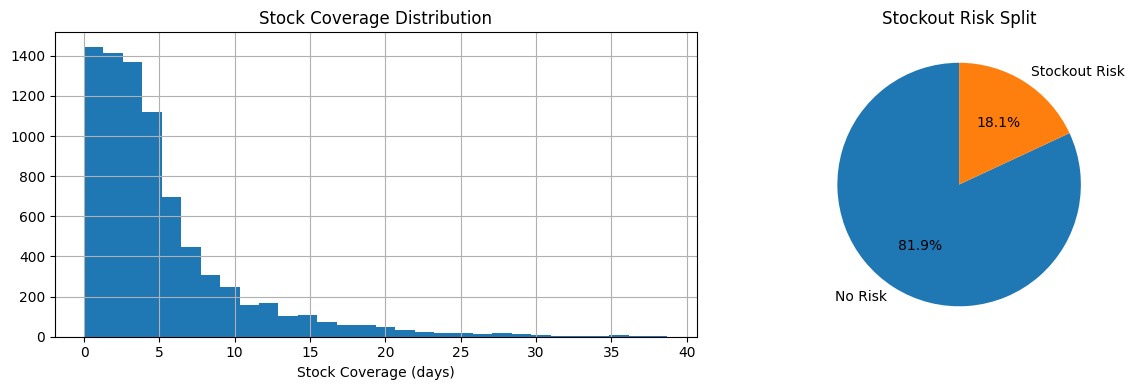

In [11]:
# ── 4. Inventory distribution ───
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

inventory['stock_coverage'].hist(bins=30, ax=axes[0])
axes[0].set_title('Stock Coverage Distribution')
axes[0].set_xlabel('Stock Coverage (days)')

stockout_counts = inventory['stockout_risk'].value_counts()
axes[1].pie(stockout_counts, labels=['No Risk', 'Stockout Risk'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Stockout Risk Split')

plt.tight_layout()
plt.show()

---
## Perspective 3 — Supplier & Procurement
**Goal:** Predict `lead_time_days` (regression)  
**Model:** Random Forest Regressor

In [12]:
# ── 1. Prepare data ───
# Merge procurement with supplier profile
df3 = procurement.merge(supplier, on='supplier_id', how='left')
df3 = df3[['order_quantity', 'unit_cost', 'quality_score', 'total_cost',
            'is_urgent', 'good_quality', 'avg_quality', 'avg_cost',
            'urgent_orders', 'reliability_index', 'lead_time_days']].dropna()

X3 = df3.drop('lead_time_days', axis=1)
y3 = df3['lead_time_days']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)
print(f'Train: {X3_train.shape} | Test: {X3_test.shape}')
print(f'Lead time — mean: {y3.mean():.1f} days, std: {y3.std():.1f} days')

Train: (2400, 10) | Test: (600, 10)
Lead time — mean: 32.8 days, std: 16.1 days


In [13]:
# ── 2. Train ───
model3 = RandomForestRegressor(n_estimators=100, random_state=42)
model3.fit(X3_train, y3_train)

y3_pred = model3.predict(X3_test)
mae = mean_absolute_error(y3_test, y3_pred)
r2  = r2_score(y3_test, y3_pred)
print(f'MAE : {mae:.2f} days')
print(f'R²  : {r2:.4f}')

MAE : 14.26 days
R²  : -0.1087


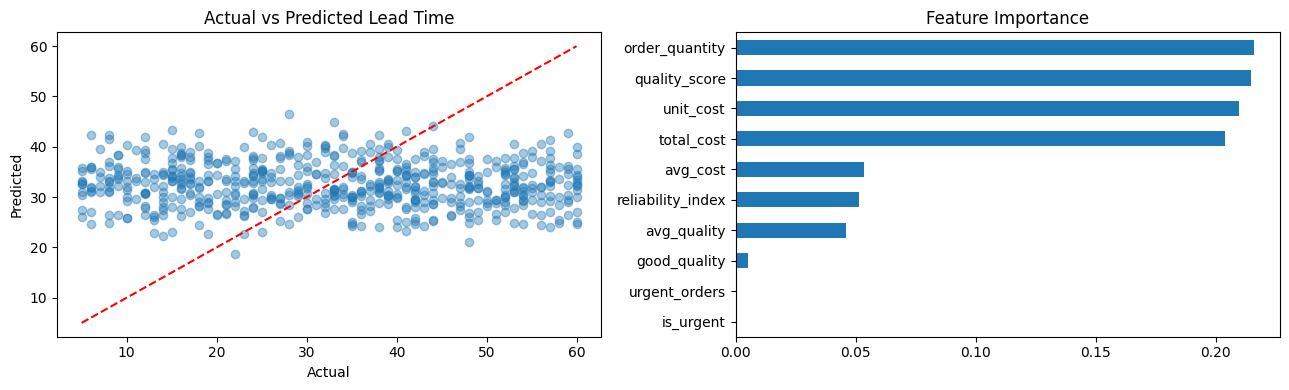

In [14]:
# ── 3. Visualise ───
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Actual vs Predicted
axes[0].scatter(y3_test, y3_pred, alpha=0.4)
axes[0].plot([y3_test.min(), y3_test.max()],
             [y3_test.min(), y3_test.max()], 'r--')
axes[0].set_title('Actual vs Predicted Lead Time')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

# Feature importance
imp3 = pd.Series(model3.feature_importances_, index=X3.columns).sort_values()
imp3.plot(kind='barh', ax=axes[1])
axes[1].set_title('Feature Importance')

plt.tight_layout()
plt.show()

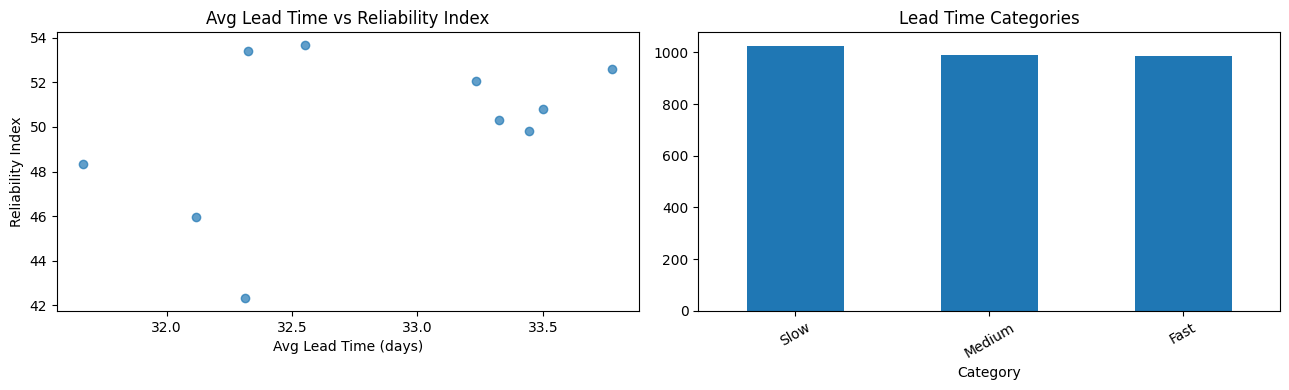

In [15]:
# ── 4. Supplier reliability overview ───
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(supplier['avg_lead_time'], supplier['reliability_index'], alpha=0.7)
axes[0].set_title('Avg Lead Time vs Reliability Index')
axes[0].set_xlabel('Avg Lead Time (days)')
axes[0].set_ylabel('Reliability Index')

procurement['lead_time_category'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Lead Time Categories')
axes[1].set_xlabel('Category')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## Perspective 4 — Production Quality
**Goal:** Predict whether a batch has defects (`has_defects`)  
**Model:** Random Forest Classifier

In [16]:
# ── 1. Prepare data ──
df4 = production[['quantity_produced', 'defective_units', 'defect_rate_pct',
                   'efficiency', 'waste_cost', 'has_defects']].dropna()

# Drop defective_units to avoid data leakage
X4 = df4.drop(['has_defects', 'defective_units'], axis=1)
y4 = df4['has_defects']

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)
print(f'Train: {X4_train.shape} | Test: {X4_test.shape}')
print(f'Defect rate: {y4.mean():.2%}')

Train: (7200, 4) | Test: (1800, 4)
Defect rate: 97.54%


In [17]:
# ── 2. Train ──
model4 = RandomForestClassifier(n_estimators=100, random_state=42)
model4.fit(X4_train, y4_train)

y4_pred = model4.predict(X4_test)
print(classification_report(y4_test, y4_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00      1755

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



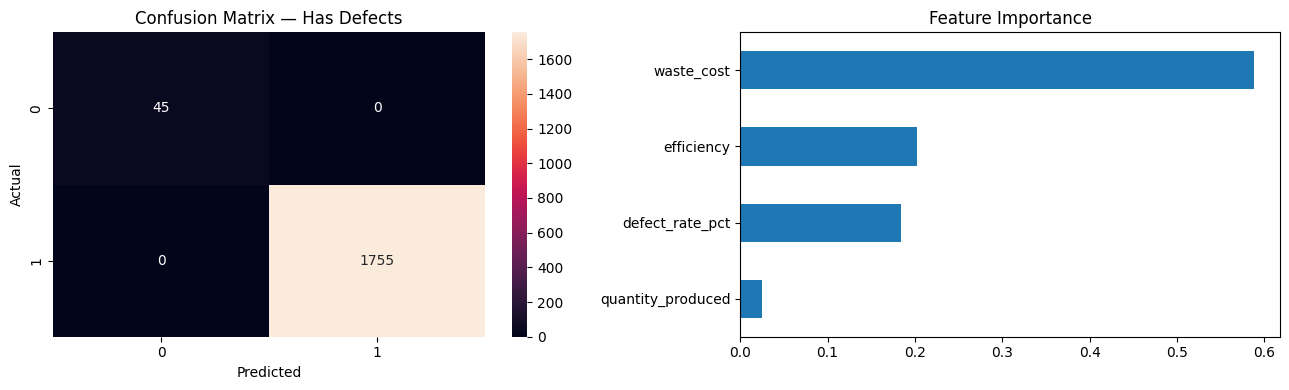

In [18]:
# ── 3. Visualise ───
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
cm4 = confusion_matrix(y4_test, y4_pred)
sns.heatmap(cm4, annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Confusion Matrix — Has Defects')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance
imp4 = pd.Series(model4.feature_importances_, index=X4.columns).sort_values()
imp4.plot(kind='barh', ax=axes[1])
axes[1].set_title('Feature Importance')

plt.tight_layout()
plt.show()

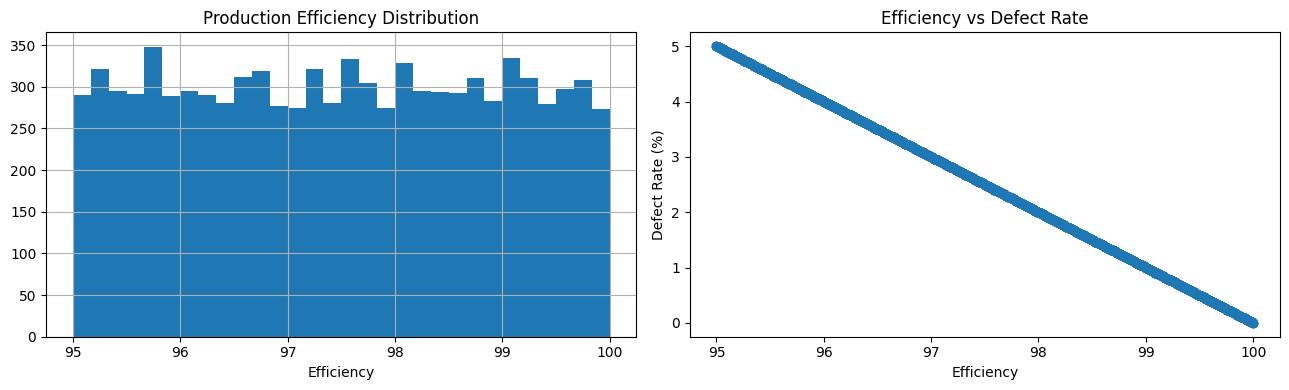

In [19]:
# ── 4. Production efficiency & defect overview ───
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

production['efficiency'].hist(bins=30, ax=axes[0])
axes[0].set_title('Production Efficiency Distribution')
axes[0].set_xlabel('Efficiency')

axes[1].scatter(production['efficiency'], production['defect_rate_pct'], alpha=0.4)
axes[1].set_title('Efficiency vs Defect Rate')
axes[1].set_xlabel('Efficiency')
axes[1].set_ylabel('Defect Rate (%)')

plt.tight_layout()
plt.show()

---
## Summary Dashboard — All 4 Models

In [20]:
from sklearn.metrics import accuracy_score

summary = pd.DataFrame({
    'Perspective'  : ['Sales (High Profit)', 'Inventory (Stockout)', 'Supplier (Lead Time)', 'Production (Defects)'],
    'Model'        : ['RF Classifier', 'Logistic Regression', 'RF Regressor', 'RF Classifier'],
    'Target'       : ['high_profit', 'stockout_risk', 'lead_time_days', 'has_defects'],
    'Type'         : ['Classification', 'Classification', 'Regression', 'Classification'],
    'Score'        : [
        f"Acc: {accuracy_score(y1_test, y1_pred):.2%}",
        f"Acc: {accuracy_score(y2_test, y2_pred):.2%}",
        f"R²: {r2_score(y3_test, y3_pred):.4f} | MAE: {mean_absolute_error(y3_test, y3_pred):.2f}d",
        f"Acc: {accuracy_score(y4_test, y4_pred):.2%}"
    ]
})

print(summary.to_string(index=False))

         Perspective               Model         Target           Type                     Score
 Sales (High Profit)       RF Classifier    high_profit Classification              Acc: 100.00%
Inventory (Stockout) Logistic Regression  stockout_risk Classification               Acc: 99.50%
Supplier (Lead Time)        RF Regressor lead_time_days     Regression R²: -0.1087 | MAE: 14.26d
Production (Defects)       RF Classifier    has_defects Classification              Acc: 100.00%
